## **Carregamento da base de dados**

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import requests
from PIL import Image
from io import BytesIO

In [113]:
sns.set(rc={'figure.figsize':(9.66,6)}, palette='tab10')

In [55]:
path_despesas = "../data/despesas.csv"
path_deputados = "../data/deputados.csv"

In [56]:
df_deputados = pd.read_csv(path_deputados)
df_despesas = pd.read_csv(path_despesas)

In [57]:
df_deputados.head()

,id,uri,nomeParlamentar,siglaPartido,uriPartido,siglaUf,idLegislatura,urlFoto,email,sexo,ultimaSituacao,condicaoEleitoral,nomeEleitoral,nomeCivil,dataNascimento,falecido,udNascimento,escolaridade
0,1500,https://dadosabertos.camara.leg.br/api/v2/depu...,MÁRIO LIMA,"['PMDB', 'PSB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['BA'],"[48, 42, 47]",https://www.camara.leg.br/internet/deputado/ba...,NaN,M,Vacância,Titular,MÁRIO LIMA,MÁRIO SOARES LIMA,1935-02-19,0,BA,Secundário
1,1501,https://dadosabertos.camara.leg.br/api/v2/depu...,MAURÍCIO FRUET,"['PMDB', 'MDB*']",https://dadosabertos.camara.leg.br/api/v2/part...,['PR'],"[48, 46, 47]",https://www.camara.leg.br/internet/deputado/ba...,NaN,M,Vacância,Titular,MAURÍCIO FRUET,Maurício Roslindo Fruet,1939-08-12,0,PR,Superior
2,1502,https://dadosabertos.camara.leg.br/api/v2/depu...,OSWALDO ALMEIDA,['PL*'],https://dadosabertos.camara.leg.br/api/v2/part...,['RJ'],[48],https://www.camara.leg.br/internet/deputado/ba...,NaN,M,NaN,Titular,OSWALDO ALMEIDA,Oswaldo Barreto de Almeida,1933-10-22,0,RJ,Superior
3,1503,https://dadosabertos.camara.leg.br/api/v2/depu...,OSWALDO LIMA FILHO,"['PMDB', 'PSP', 'MDB*', 'PTB']",https://dadosabertos.camara.leg.br/api/v2/part...,['PE'],"[40, 41, 42, 43, 47, 48]",https://www.camara.leg.br/internet/deputado/ba...,NaN,M,Vacância,Efetivado,OSWALDO LIMA FILHO,Oswaldo Cavalcanti da Costa Lima Filho,1921-04-26,0,PE,Superior
4,1504,https://dadosabertos.camara.leg.br/api/v2/depu...,TITO COSTA,['PMDB'],https://dadosabertos.camara.leg.br/api/v2/part...,['SP'],[48],https://www.camara.leg.br/internet/deputado/ba...,NaN,M,NaN,Suplente,TITO COSTA,Antonio Tito Costa,1922-12-31,0,SP,Superior


In [58]:
df_deputados.ultimaSituacao.value_counts()

ultimaSituacao
Vacância          1791
Fim de Mandato     989
Exercício          526
Suplência          289
Afastado           189
Licença             43
Convocado            4
Suspenso             1
Name: count, dtype: int64

In [59]:
df_despesas.head()

,ano,mes,tipoDespesa,codDocumento,tipoDocumento,codTipoDocumento,dataDocumento,numDocumento,valorDocumento,urlDocumento,nomeFornecedor,cnpjCpfFornecedor,valorLiquido,valorGlosa,numRessarcimento,codLote,parcela,id_deputado
0,2023,9,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7610066,Nota Fiscal Eletrônica,4,2023-09-19T00:00:00,35537,52.98,http://www.camara.leg.br/cota-parlamentar/nota...,3XIS COMERCIO VAREJISTA E ATACADISTA DE PAPELA...,4.299980e+13,52.98,0.0,NaN,1969221,0,220593
1,2023,11,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7657491,Nota Fiscal,0,2023-11-27T00:00:00,01,67.30,https://www.camara.leg.br/cota-parlamentar/doc...,AGUAS CUIABA S.A,1.499558e+13,67.30,0.0,NaN,1996163,0,220593
2,2023,5,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7552621,Nota Fiscal,0,2023-05-05T00:00:00,11533052023001,43.20,https://www.camara.leg.br/cota-parlamentar/doc...,AGUAS CUIABA S.A,1.499558e+13,43.20,0.0,NaN,1938600,0,220593
3,2023,6,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7587236,Recibos/Outros,1,2023-06-05T00:00:00,11533062023001,43.20,https://www.camara.leg.br/cota-parlamentar/doc...,AGUAS CUIABA S.A,1.499558e+13,43.20,0.0,NaN,1957493,0,220593
4,2023,7,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,7587239,Nota Fiscal,0,2023-07-05T00:00:00,11533072023001,43.20,https://www.camara.leg.br/cota-parlamentar/doc...,AGUAS CUIABA S.A,1.499558e+13,43.20,0.0,NaN,1957494,0,220593


In [60]:
df_despesas.numRessarcimento.sort_values(ascending=False).head(10)

523    0.0
524    0.0
525    0.0
526    0.0
527    0.0
528    0.0
529    0.0
530    0.0
531    0.0
532    0.0
Name: numRessarcimento, dtype: float64

In [61]:
df_despesas["parcela"].value_counts().head(10)

parcela
0    656813
1       349
Name: count, dtype: int64

In [62]:
df_despesas.valorGlosa.value_counts().head(10)

valorGlosa
0.00     627515
3.00        500
2.99        443
4.00        362
5.00        326
20.00       186
10.00       180
2.00        173
4.50        163
2.50        147
Name: count, dtype: int64

In [63]:
df_despesas.nomeFornecedor.value_counts()

nomeFornecedor
TAM                                      95869
UBER DO BRASIL TECNOLOGIA LTDA.          32083
GOL                                      29321
AZUL                                     26112
LATAM Airlines Brasil                     7749
                                         ...  
POA APARICIO BORGES                          1
SAMUARA HOTEL                                1
real expresso                                1
ABAST DE COMB MAGISTERIO LTDA                1
COM DE COMB CAVALINHO LTDA F15 OSORIO        1
Name: count, Length: 42447, dtype: int64

In [64]:
df_despesas.valorDocumento.sort_values(ascending=False).head(10)

209285    209948.0
24190     178433.0
292738    164900.0
536003    150960.0
593282    149000.0
290877    148500.0
139407    140000.0
37597     140000.0
599447    130000.0
36737     130000.0
Name: valorDocumento, dtype: float64

In [65]:
df_despesas.numDocumento.value_counts().head(10)

numDocumento
s/n     10068
S/N      8784
sn       5247
SN       3553
00        998
S/Nº      888
10        656
3         654
4         638
11        624
Name: count, dtype: int64

In [66]:
df_despesas.tipoDocumento.unique()

<StringArray>
['Nota Fiscal Eletrônica',            'Nota Fiscal',         'Recibos/Outros',
    'Despesa no Exterior',    'Despesa do PARLASUL']
Length: 5, dtype: str

## **Características iniciais dos dados**

In [67]:
df_deputados.shape

(5190, 18)

In [68]:
df_deputados.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 5190 non-null   int64
 1   uri                5190 non-null   str  
 2   nomeParlamentar    5190 non-null   str  
 3   siglaPartido       5190 non-null   str  
 4   uriPartido         5187 non-null   str  
 5   siglaUf            5190 non-null   str  
 6   idLegislatura      5190 non-null   str  
 7   urlFoto            5190 non-null   str  
 8   email              513 non-null    str  
 9   sexo               5190 non-null   str  
 10  ultimaSituacao     3832 non-null   str  
 11  condicaoEleitoral  5145 non-null   str  
 12  nomeEleitoral      5190 non-null   str  
 13  nomeCivil          5190 non-null   str  
 14  dataNascimento     5155 non-null   str  
 15  falecido           5190 non-null   int64
 16  udNascimento       5106 non-null   str  
 17  escolaridade       4755 n

In [69]:
df_deputados.isnull().sum()

id                      0
uri                     0
nomeParlamentar         0
siglaPartido            0
uriPartido              3
siglaUf                 0
idLegislatura           0
urlFoto                 0
email                4677
sexo                    0
ultimaSituacao       1358
condicaoEleitoral      45
nomeEleitoral           0
nomeCivil               0
dataNascimento         35
falecido                0
udNascimento           84
escolaridade          435
dtype: int64

In [70]:
df_deputados.columns

Index(['id', 'uri', 'nomeParlamentar', 'siglaPartido', 'uriPartido', 'siglaUf',
       'idLegislatura', 'urlFoto', 'email', 'sexo', 'ultimaSituacao',
       'condicaoEleitoral', 'nomeEleitoral', 'nomeCivil', 'dataNascimento',
       'falecido', 'udNascimento', 'escolaridade'],
      dtype='str')

In [71]:
df_deputados.groupby(['sexo', 'siglaUf']).size()

sexo  siglaUf     
F     ['AC']           13
      ['AL']            4
      ['AM']            7
      ['AP']           14
      ['BA']           16
                     ... 
M     ['SC']          183
      ['SE']          100
      ['SP', 'PE']      1
      ['SP']          643
      ['TO']           50
Length: 80, dtype: int64

In [72]:
df_deputados.escolaridade.unique()

<StringArray>
[             'Secundário',                'Superior',
                       nan,          'Ensino Técnico',
           'Pós-Graduação',                'Primário',
     'Superior Incompleto',                'Mestrado',
                'Ginasial',   'Secundário Incompleto',
               'Doutorado',      'Ensino Fundamental',
            'Ensino Médio',     'Primário Incompleto',
    'Doutorado Incompleto', 'Ensino Médio Incompleto',
     'Mestrado Incompleto']
Length: 17, dtype: str

In [73]:
df_deputados.siglaPartido.value_counts()

siglaPartido
['PMDB']                               423
['PSD']                                377
['PT']                                 309
['PTB']                                265
['ARENA']                              206
                                      ... 
['S.PART.', 'SOLIDARIEDADE', 'PSB']      1
['S.PART.', 'PL', 'MDB']                 1
['REPUBLICANOS', 'PV']                   1
['PDT', 'PODE']                          1
['REPUBLICANOS', 'UNIÃO']                1
Name: count, Length: 920, dtype: int64

In [74]:
df_deputados.sexo.value_counts()

sexo
M    4845
F     345
Name: count, dtype: int64

In [75]:
df_deputados.falecido.value_counts()

falecido
0    5151
1      39
Name: count, dtype: int64

## **Limpeza dos dados**

In [76]:
df_despesas.columns

Index(['ano', 'mes', 'tipoDespesa', 'codDocumento', 'tipoDocumento',
       'codTipoDocumento', 'dataDocumento', 'numDocumento', 'valorDocumento',
       'urlDocumento', 'nomeFornecedor', 'cnpjCpfFornecedor', 'valorLiquido',
       'valorGlosa', 'numRessarcimento', 'codLote', 'parcela', 'id_deputado'],
      dtype='str')

In [77]:
df_despesas.drop(columns='codDocumento', inplace=True)

In [78]:
df_despesas.drop(columns='numDocumento', inplace=True)

In [79]:
df_despesas.drop(columns='cnpjCpfFornecedor', inplace=True)

In [80]:
df_despesas.drop(columns='numRessarcimento', inplace=True)

In [81]:
df_despesas.drop(columns='valorGlosa', inplace=True)

In [82]:
df_despesas.drop(columns='codLote', inplace=True)

In [83]:
df_despesas.drop(columns='parcela', inplace=True)

In [84]:
df_despesas.columns

Index(['ano', 'mes', 'tipoDespesa', 'tipoDocumento', 'codTipoDocumento',
       'dataDocumento', 'valorDocumento', 'urlDocumento', 'nomeFornecedor',
       'valorLiquido', 'id_deputado'],
      dtype='str')

### **Padronização de dados**

In [85]:
df_despesas.columns

Index(['ano', 'mes', 'tipoDespesa', 'tipoDocumento', 'codTipoDocumento',
       'dataDocumento', 'valorDocumento', 'urlDocumento', 'nomeFornecedor',
       'valorLiquido', 'id_deputado'],
      dtype='str')

In [86]:
novasColunasPadronizadas = {
    'tipoDespesa': 'tipo_despesa',
    'tipoDocumento': 'tipo_documento',
    'codTipoDocumento': 'cod_tipo_documento',
    'dataDocumento': 'data_documento',
    'valorDocumento': 'valor_documento',
    'urlDocumento': 'url_documento',
    'nomeFornecedor': 'nome_fornecedor',
    'valorLiquido': 'valor_liquido'
}

df_despesas.rename(columns=novasColunasPadronizadas, inplace=True)

print(df_despesas.columns)

Index(['ano', 'mes', 'tipo_despesa', 'tipo_documento', 'cod_tipo_documento',
       'data_documento', 'valor_documento', 'url_documento', 'nome_fornecedor',
       'valor_liquido', 'id_deputado'],
      dtype='str')


In [87]:
df_despesas.ano   #coluna com padronização já realizada, sem necessidade de renomear

0         2023
1         2023
2         2023
3         2023
4         2023
          ... 
657157    2026
657158    2026
657159    2026
657160    2026
657161    2026
Name: ano, Length: 657162, dtype: int64

In [88]:
df_despesas.mes  # coluna com padronização já realizada, sem necessidade de renomear. O uso de int permite a ordenamento correto dos meses, ao contrário de uma coluna do tipo string.

0          9
1         11
2          5
3          6
4          7
          ..
657157     1
657158     1
657159     1
657160     1
657161     1
Name: mes, Length: 657162, dtype: int64

In [89]:
df_despesas.mes.value_counts()

mes
3     62012
5     61685
10    59914
4     59074
6     58741
8     57632
7     57296
9     55033
2     54331
11    53142
12    44832
1     33470
Name: count, dtype: int64

In [90]:
df_despesas.tipo_despesa.value_counts()

tipo_despesa
COMBUSTÍVEIS E LUBRIFICANTES.                                214078
PASSAGEM AÉREA - SIGEPA                                      162357
SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO                     63074
MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR     60483
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.                          50920
FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR                    31891
LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES                 22010
HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL.        21791
TELEFONIA                                                     21242
PASSAGEM AÉREA - RPA                                           2975
PASSAGENS TERRESTRES, MARÍTIMAS OU FLUVIAIS                    2351
SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA.       1430
PASSAGEM AÉREA - REEMBOLSO                                     1096
ASSINATURA DE PUBLICAÇÕES                                       774
LOCAÇÃO OU FRETAMENTO DE AERONAVES 

In [91]:
df_despesas['tipo_despesa'] = df_despesas['tipo_despesa'].str.strip()

df_despesas['tipo_despesa'] = df_despesas['tipo_despesa'].str.replace(r'\.$', '', regex=True)

df_despesas['tipo_despesa'] = df_despesas['tipo_despesa'].str.replace(' ,', ', ')

df_despesas['tipo_despesa'] = df_despesas['tipo_despesa'].str.upper()

df_despesas.loc[df_despesas['tipo_despesa'].str.contains('PASSAGEM AÉREA'), 'tipo_despesa'] = 'PASSAGEM AÉREA'

In [92]:
df_despesas.tipo_despesa.value_counts()

tipo_despesa
COMBUSTÍVEIS E LUBRIFICANTES                                 214078
PASSAGEM AÉREA                                               166428
SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO                     63074
MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR     60483
DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR                           50920
FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR                    31891
LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES                 22010
HOSPEDAGEM, EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL         21791
TELEFONIA                                                     21242
PASSAGENS TERRESTRES, MARÍTIMAS OU FLUVIAIS                    2351
SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA        1430
ASSINATURA DE PUBLICAÇÕES                                       774
LOCAÇÃO OU FRETAMENTO DE AERONAVES                              273
SERVIÇOS POSTAIS                                                187
LOCAÇÃO OU FRETAMENTO DE EMBARCAÇÕE

In [93]:
df_despesas.tipo_documento.value_counts()

tipo_documento
Nota Fiscal               362092
Nota Fiscal Eletrônica    192955
Recibos/Outros            101496
Despesa do PARLASUL          343
Despesa no Exterior          276
Name: count, dtype: int64

In [94]:
df_despesas['tipo_documento'] = df_despesas['tipo_documento'].str.strip()

df_despesas['tipo_documento'] = df_despesas['tipo_documento'].str.upper()

df_despesas.loc[df_despesas['tipo_documento'] == 'NOTA FISCAL ELETRÔNICA', 'tipo_documento'] = 'NOTA FISCAL'

df_despesas.tipo_documento.value_counts()

tipo_documento
NOTA FISCAL            555047
RECIBOS/OUTROS         101496
DESPESA DO PARLASUL       343
DESPESA NO EXTERIOR       276
Name: count, dtype: int64

In [95]:
df_despesas.cod_tipo_documento.value_counts()

cod_tipo_documento
0    362092
4    192955
1    101496
3       343
2       276
Name: count, dtype: int64

In [96]:
df_despesas.data_documento.value_counts()

data_documento
2025-10-01T00:00:00    1302
2023-08-01T00:00:00    1117
2023-11-01T00:00:00    1069
2023-06-01T00:00:00    1064
2023-09-01T00:00:00    1006
                       ... 
2025-05-14T08:59:00       1
2026-01-08T16:06:03       1
2026-01-07T07:57:40       1
2026-01-11T20:56:10       1
2026-01-12T07:53:30       1
Name: count, Length: 65936, dtype: int64

In [97]:
df_despesas['data_documento'] = pd.to_datetime(df_despesas['data_documento'], errors='coerce')

df_despesas['data_documento'] = df_despesas['data_documento'].dt.normalize()

print(df_despesas['data_documento'].head())
print("Tipo da coluna:", df_despesas['data_documento'].dtype)

0   2023-09-19
1   2023-11-27
2   2023-05-05
3   2023-06-05
4   2023-07-05
Name: data_documento, dtype: datetime64[us]
Tipo da coluna: datetime64[us]


In [98]:
# Essa coluna já possui um bom formato para a análise
df_despesas.valor_documento.sort_values(ascending=False).head(10)

209285    209948.0
24190     178433.0
292738    164900.0
536003    150960.0
593282    149000.0
290877    148500.0
139407    140000.0
37597     140000.0
599447    130000.0
36737     130000.0
Name: valor_documento, dtype: float64

In [99]:
df_despesas.nome_fornecedor.value_counts().head(10)

nome_fornecedor
TAM                                                         95869
UBER DO BRASIL TECNOLOGIA LTDA.                             32083
GOL                                                         29321
AZUL                                                        26112
LATAM Airlines Brasil                                        7749
TÁXI LEGAL                                                   4647
AUTO POSTO CINCO ESTRELAS LTDA                               4269
CELULAR FUNCIONAL                                            4127
SERVICO NACIONAL DE APRENDIZAGEM COMERCIAL SENAC             4096
031 - 302 NORTE - CASCOL COMBUSTIVEIS PARA VEICULOS LTDA     3832
Name: count, dtype: int64

In [100]:
df_despesas['nome_fornecedor'] = df_despesas['nome_fornecedor'].str.strip().str.upper()
df_despesas['nome_fornecedor'] = df_despesas['nome_fornecedor'].str.replace(r'\.$', '', regex=True)
df_despesas['nome_fornecedor'] = df_despesas['nome_fornecedor'].str.replace(r'\sLTDA$|\sS\.?A\.?$|\sME$', '', regex=True)

df_despesas.loc[df_despesas['nome_fornecedor'].isin(['TAM', 'LATAM AIRLINES BRASIL']), 'nome_fornecedor'] = 'LATAM'
df_despesas.loc[df_despesas['nome_fornecedor'].str.contains('CASCOL', na=False), 'nome_fornecedor'] = 'REDE CASCOL'
df_despesas.loc[df_despesas['nome_fornecedor'].str.contains('UBER', na=False), 'nome_fornecedor'] = 'UBER'
df_despesas.loc[df_despesas['nome_fornecedor'].str.contains('IFOOD', na=False), 'nome_fornecedor'] = 'IFOOD'
df_despesas.loc[df_despesas['nome_fornecedor'].str.contains('CORREIOS', na=False), 'nome_fornecedor'] = 'CORREIOS'

print(df_despesas['nome_fornecedor'].value_counts().head(10))

nome_fornecedor
LATAM                                               103631
UBER                                                 32767
GOL                                                  29321
AZUL                                                 26112
REDE CASCOL                                          13803
TÁXI LEGAL                                            4648
AUTO POSTO CINCO ESTRELAS                             4310
CELULAR FUNCIONAL                                     4127
SERVICO NACIONAL DE APRENDIZAGEM COMERCIAL SENAC      4097
CLARO NXT TELECOMUNICAÇÕES                            4086
Name: count, dtype: int64


In [101]:
df_despesas.valor_liquido.sort_values(ascending=False).head(10)

209285    184428.0
292738    164900.0
24190     163791.0
536003    150960.0
593282    149000.0
290877    148500.0
139407    140000.0
37597     140000.0
36737     130000.0
599447    130000.0
Name: valor_liquido, dtype: float64

In [102]:
df_despesas.to_csv('../data/despesas_tratadas.csv')

### **Análise exploratória dos dados**
Primeiro, vamos analizar a distribuição geral dos dados.

In [103]:
df_deputados = pd.read_csv("../data/deputados_tratados.csv")

In [110]:
#a fim de costume e praticidade, usaremos a variavel df para representar o dataframe de despesas
df = df_despesas
df.head()

,ano,mes,tipo_despesa,tipo_documento,cod_tipo_documento,data_documento,valor_documento,url_documento,nome_fornecedor,valor_liquido,id_deputado
0,2023,9,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,NOTA FISCAL,4,2023-09-19,52.98,http://www.camara.leg.br/cota-parlamentar/nota...,3XIS COMERCIO VAREJISTA E ATACADISTA DE PAPELARIA,52.98,220593
1,2023,11,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,NOTA FISCAL,0,2023-11-27,67.30,https://www.camara.leg.br/cota-parlamentar/doc...,AGUAS CUIABA,67.30,220593
2,2023,5,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,NOTA FISCAL,0,2023-05-05,43.20,https://www.camara.leg.br/cota-parlamentar/doc...,AGUAS CUIABA,43.20,220593
3,2023,6,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,RECIBOS/OUTROS,1,2023-06-05,43.20,https://www.camara.leg.br/cota-parlamentar/doc...,AGUAS CUIABA,43.20,220593
4,2023,7,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,NOTA FISCAL,0,2023-07-05,43.20,https://www.camara.leg.br/cota-parlamentar/doc...,AGUAS CUIABA,43.20,220593


/tmp/ipykernel_50261/1137306507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(df, y='tipo_documento', palette='tab10')


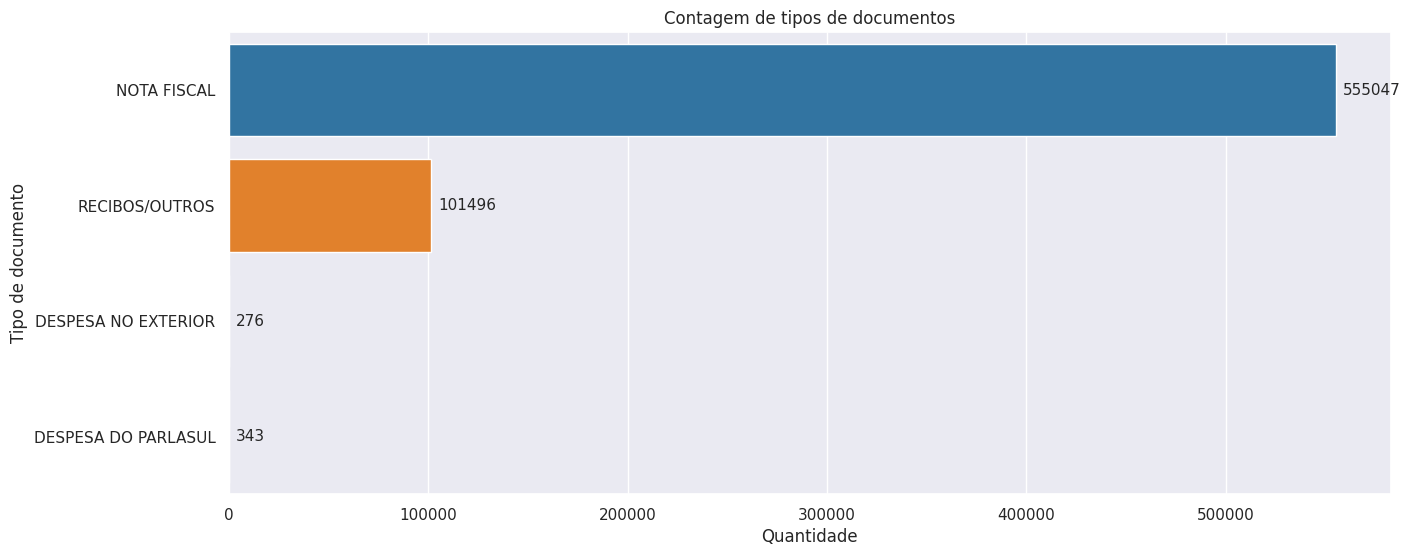

In [121]:
plt.figure(figsize=(15, 6))
fig = sns.countplot(df, y='tipo_documento', palette='tab10')
fig.set(title="Contagem de tipos de documentos", xlabel="Quantidade", ylabel="Tipo de documento")

for c in fig.containers:
    fig.bar_label(c, fontsize=11, padding=5)

<Axes: xlabel='valor_liquido', ylabel='Count'>

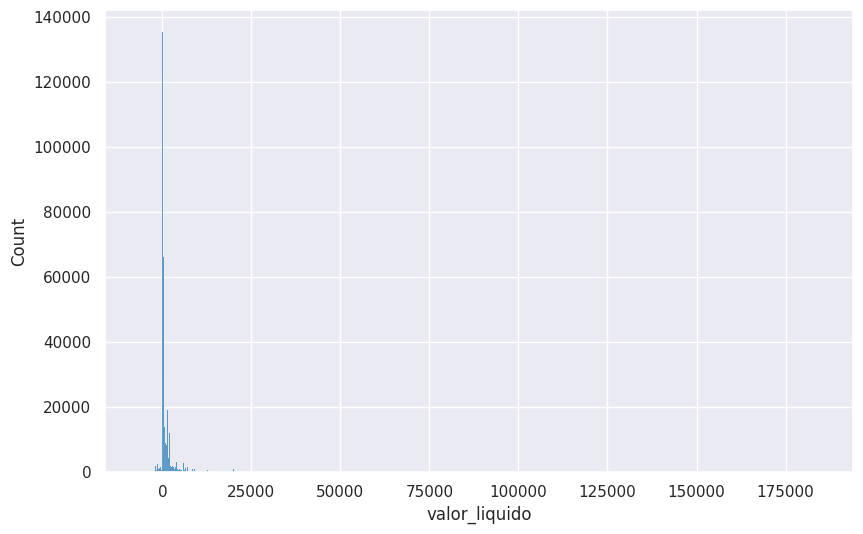

In [124]:
sns.histplot(df, x='valor_liquido')